In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
m = 50
n = 32

In [8]:
def fjk(j, k):
    return (k+1) / np.sqrt(m) * np.exp(2 * np.pi * 1j * j * k / m)
v = np.arange(1, n + 1)

In [9]:
T = np.fromfunction(fjk, (32, 50))
S = T @ T.conjugate().T

In [28]:
def get_bounds(T):
    svdvals = np.linalg.svdvals(T)
    return svdvals[-1] ** 2, svdvals[0] ** 2

In [6]:
def get_decomposition(T, f):
    return np.linalg.pinv(T) @ f

## Frame bounds

In [29]:
bounds = get_bounds(T)
A, B = bounds
print("Frame bounds:")
bounds

Frame bounds:


(np.float64(7.375000124181121), np.float64(2392.9956154058996))

## Frame decomposition

In [8]:
decomp = get_decomposition(T, v)
print("Exact frame decomposition:")
decomp

Exact frame decomposition:


array([ 2.05036512-1.18636257e+00j, -7.33464896-5.09242198e+00j,
       -1.25297325+8.55823414e+00j, -1.19483066-5.20429149e-01j,
        2.14815314+3.13263115e+00j, -1.56211634+1.42688580e+00j,
        1.48312228+9.83215930e-02j,  0.12472113+2.32344046e+00j,
       -0.47315812-9.51546115e-02j,  1.25909009+9.53012994e-01j,
       -0.63778451+1.28403769e+00j,  0.26286426-2.25290041e-01j,
        0.58146049+1.29751214e+00j, -0.73673048+4.87937818e-01j,
        0.58888321+8.82539423e-02j, -0.07667629+1.23882642e+00j,
       -0.51571216+4.99299173e-03j,  0.56813097+4.87505941e-01j,
       -0.55214617+9.22614329e-01j, -0.19147146-1.77775738e-01j,
        0.29704456+7.91211218e-01j, -0.78943155+4.88551355e-01j,
        0.08723726-1.18730467e-01j, -0.11178569+9.06931762e-01j,
       -0.79655688+5.81999827e-02j,  0.2256866 +9.32210723e-02j,
       -0.54455647+8.04930802e-01j, -0.62509355-2.76690352e-01j,
        0.18011688+3.53990262e-01j, -0.90134663+5.03037736e-01j,
       -0.35200802-4.6333

## Frame algorithm

In [105]:
residual = np.inf
fn = np.zeros_like(v, dtype=np.complex128)
c = T.conjugate().T @ v
n = 1
Sf = T @ c
residuals = []
while np.abs(residual) > 1e-5:
    fn += 2 / (A + B) * (Sf - S @ fn)
    residual = np.power((B - A) / (B + A), n) * np.linalg.norm(fn)
    true_residual = np.linalg.norm(fn - v)
    residuals.append(residual)
    n += 1

In [106]:
print("Reconstructed v:")
fn

Reconstructed v:


array([ 1.00000003+2.37188488e-09j,  2.0000002 +7.56418864e-08j,
        3.00000036+1.79778279e-07j,  4.0000005 +2.92034708e-07j,
        5.0000006 +3.98885146e-07j,  6.00000065+4.91270570e-07j,
        7.00000066+5.63083140e-07j,  8.00000062+6.10554996e-07j,
        9.00000054+6.31931230e-07j, 10.00000041+6.27219644e-07j,
       11.00000024+5.97941880e-07j, 12.00000005+5.46862266e-07j,
       12.99999984+4.77693532e-07j, 13.99999962+3.94789274e-07j,
       14.99999941+3.02838152e-07j, 15.99999921+2.06575542e-07j,
       16.99999904+1.10527814e-07j, 17.99999891+1.88013811e-08j,
       18.99999882-6.50748059e-08j, 19.99999878-1.38249210e-07j,
       20.99999879-1.98590044e-07j, 21.99999885-2.44674661e-07j,
       22.99999896-2.75734252e-07j, 23.99999911-2.91565317e-07j,
       24.99999929-2.92421996e-07j, 25.99999949-2.78906457e-07j,
       26.99999969-2.51878864e-07j, 27.99999989-2.12419902e-07j,
       29.00000006-1.61913647e-07j, 30.00000019-1.02434177e-07j,
       31.00000026-3.8084

## Conjugate Gradient acceleration for the Frame algorithm

In [127]:
# naive version from the paper
c = T.conjugate().T @ v
r = T @ c
p = r.copy()
Sp = S @ p
x = np.zeros_like(p)
λ = np.vdot(r, p) / np.vdot(p, Sp)
x += λ * p
r -= λ * Sp
p_new = Sp - (np.vdot(Sp, Sp) / np.vdot(p, Sp)) * p
p_old = p
Spold = Sp
p = p_new
errors_cg = []
num_iter = 3600
for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg.append(norm)

    Sp = S @ p
    λ = np.vdot(r, p) / np.vdot(p, Sp)
    x += λ * p
    r -= λ * Sp

    if norm < 1e-5:
        errors_cg.append(np.linalg.norm(x - v))
        break
    p_new = Sp - (np.vdot(Sp, Sp) / np.vdot(p, Sp)) * p - (np.vdot(Sp, Spold) / np.vdot(p_old, Spold)) * p_old
    p_old = p
    Spold = Sp
    p = p_new



In [128]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 1.00000009+5.94678253e-08j,  2.00000018+6.53011252e-08j,
        3.00000018+6.87297223e-08j,  4.00000015+1.87898083e-07j,
        5.00000021+3.70926485e-07j,  6.00000024+4.94115823e-07j,
        7.00000002+6.67285381e-07j,  7.99999966+1.00114280e-06j,
        8.99999927+1.07020322e-06j,  9.99999856+6.72916645e-07j,
       10.99999804+2.20014317e-07j, 11.9999984 -1.29527504e-06j,
       12.99999961-1.05386335e-06j, 13.99999965-6.64748960e-07j,
       14.99999976-6.10521243e-07j, 15.9999998 -3.70757292e-07j,
       16.99999955-3.29818549e-07j, 17.99999947-5.29454392e-07j,
       18.99999934-6.09669914e-07j, 19.99999906-1.40764108e-06j,
       21.00000045-2.13159842e-06j, 22.00000106-1.13572296e-06j,
       23.00000131-6.03918867e-07j, 24.00000096-1.13884500e-07j,
       25.00000069+2.52781363e-07j, 26.00000049+2.47387497e-07j,
       27.00000023+1.73133800e-07j, 28.00000009+2.02275093e-07j,
       29.0000001 +1.95247208e-07j, 30.0000001 +1.03071729e-07j,
       31.00000001+4.2775

In [129]:
# reformulated two-term p_n version from the paper
c = T.conjugate().T @ v
r = T @ c
p = r.copy()
Sp = S @ p
x = np.zeros_like(p)
errors_cg_two = []
num_iter = 300

for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg_two.append(norm)

    Sp = S @ p
    λ = np.vdot(r, p) / np.vdot(p, Sp)
    x += λ * p
    r -= λ * Sp

    if norm < 1e-5:
        errors_cg_two.append(np.linalg.norm(x - v))
        break
    p_new = r - (np.vdot(r, Sp) / np.vdot(p, Sp)) * p
    p = p_new

In [130]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 1.        -5.13247295e-08j,  1.99999995-1.09679037e-07j,
        2.99999988-1.20209677e-07j,  3.99999987-8.91678837e-08j,
        4.99999992-6.45254093e-08j,  6.00000001-1.03048959e-07j,
        7.00000008-2.16386012e-07j,  8.00000007-3.36298905e-07j,
        9.00000003-3.58317898e-07j, 10.0000001 -2.78329558e-07j,
       11.00000037-2.78423925e-07j, 12.00000067-4.50474226e-07j,
       13.00000073-3.32372866e-07j, 14.00000085+3.78690338e-07j,
       15.00000106+5.59916420e-07j, 16.00000006+5.49226751e-07j,
       17.00000077+9.61108268e-07j, 17.99999993+7.66041207e-07j,
       18.99999955+9.62435609e-07j, 19.99999964+5.31322532e-07j,
       20.99999959+1.19004954e-07j, 21.99999955+9.44864250e-08j,
       22.99999965+1.59645888e-07j, 23.99999981+1.07323342e-07j,
       24.99999988-1.39783649e-08j, 25.99999986-8.82487095e-08j,
       26.99999982-7.29520438e-08j, 27.99999983-9.13315382e-09j,
       28.9999999 +3.77131534e-08j, 29.99999999+3.24393460e-08j,
       31.00000004-1.1848

In [131]:
# classic version of CG for linear equations
r = T @ c
p = r.copy()
x = np.zeros_like(v, dtype=np.complex128)
errors_cg_classic = []
num_iter = 6800

for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg_classic.append(norm)

    Sp = S @ p
    alpha = np.vdot(r, r) / np.vdot(p, Sp)

    x_new = x + alpha * p
    r_new = r - alpha * Sp

    if norm < 1e-5:
        x = x_new
        errors_cg_classic.append(np.linalg.norm(x - v))
        break

    beta = np.vdot(r_new, r_new) / np.vdot(r, r)

    p = r_new + beta * p
    x = x_new
    r = r_new


In [124]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 1.-2.22587329e-10j,  2.+8.88390601e-11j,  3.+4.33703677e-10j,
        4.+4.45778284e-10j,  5.+8.99607928e-11j,  6.-2.91465445e-10j,
        7.-3.01782987e-10j,  8.+9.65805206e-11j,  9.+4.98084650e-10j,
       10.+4.37475181e-10j, 11.-7.31398950e-11j, 12.-4.73906181e-10j,
       13.-2.82601470e-10j, 14.+2.95459605e-10j, 15.+5.91719410e-10j,
       16.+2.93816324e-10j, 17.-2.03063629e-10j, 18.-3.71418634e-10j,
       19.-1.75085248e-10j, 20.+1.03984042e-10j, 21.+3.03774539e-10j,
       22.+3.68834640e-10j, 23.+2.08106122e-10j, 24.-1.48863643e-10j,
       25.-4.06273737e-10j, 26.-2.74191741e-10j, 27.+1.49757248e-10j,
       28.+4.62841839e-10j, 29.+3.84487450e-10j, 30.-1.85997341e-12j,
       31.-3.58052354e-10j, 32.-3.77758818e-10j])

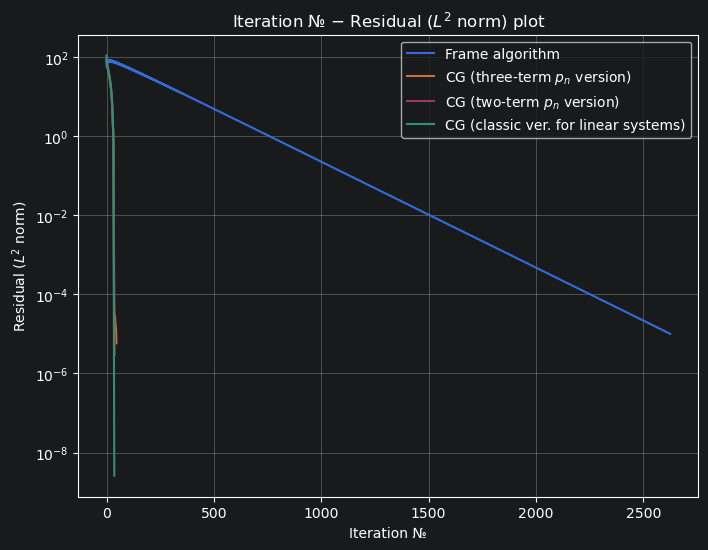

In [132]:
plt.figure(figsize=(8,6))
plt.xlabel("Iteration №")
plt.ylabel("Residual ($L^2$ norm)")
plt.grid(True)
plt.semilogy(residuals, label='Frame algorithm')
plt.semilogy(errors_cg, label='CG (three-term $p_n$ version)')
plt.semilogy(errors_cg_two, label='CG (two-term $p_n$ version)')
plt.semilogy(errors_cg_classic, label='CG (classic ver. for linear systems)')
plt.title("Iteration № $-$ Residual ($L^2$ norm) plot")
plt.legend()
plt.show()

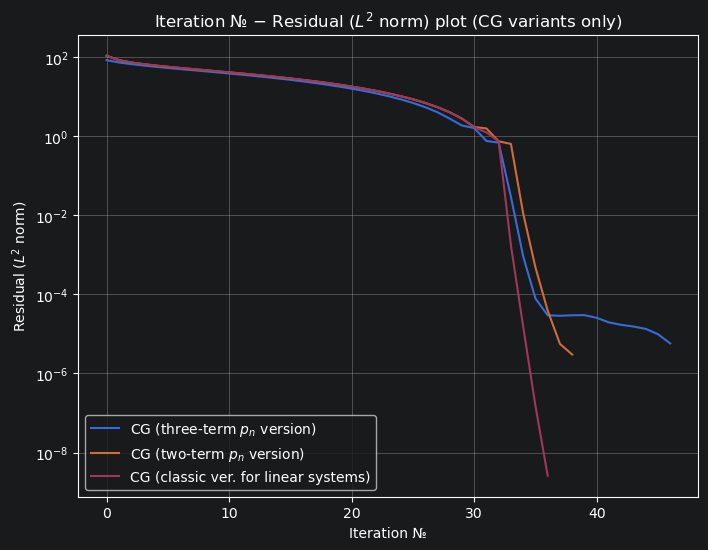

In [133]:
plt.figure(figsize=(8,6))
plt.xlabel("Iteration №")
plt.ylabel("Residual ($L^2$ norm)")
plt.grid(True)
plt.semilogy(errors_cg, label='CG (three-term $p_n$ version)')
plt.semilogy(errors_cg_two, label='CG (two-term $p_n$ version)')
plt.semilogy(errors_cg_classic, label='CG (classic ver. for linear systems)')
plt.title("Iteration № $-$ Residual ($L^2$ norm) plot (CG variants only)")
plt.legend()
plt.show()